## Day 2: Classification in Python



## Learning Outcomes
- Logistic regression
- Sigmoid functions
- Log loss and regularisation
- Classification thresholds
- Confusion matrices
- Accuracy, Recall, Precision, F1
- ROC and AUC
- Multiclass classification
- Feature selection
- Decision trees and random forests
- Cross-validation
- Overfitting and underfitting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import permutation_importance


## Example 1: Breast Cancer Dataset

In [2]:
cancer=load_breast_cancer(as_frame=True)
df=cancer.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Logistic Regression

In [3]:
X=df.drop(columns="target")
y=df.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
model=LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)
probs=model.predict_proba(X_test)[:,1]
preds=model.predict(X_test)
print("Accuracy",accuracy_score(y_test,preds))

Accuracy 0.9766081871345029


## Sigmoid Function

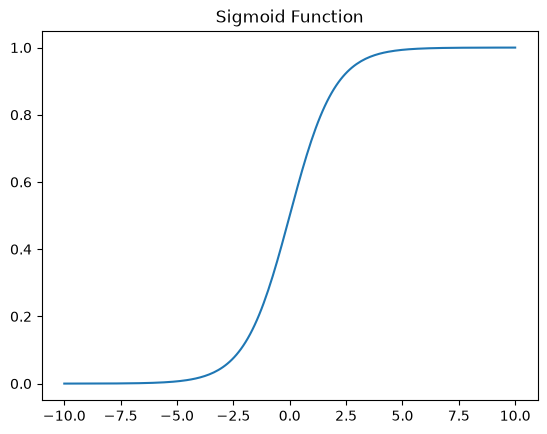

In [4]:
x=np.linspace(-10,10,200)
y=1/(1+np.exp(-x))
plt.plot(x,y)
plt.title("Sigmoid Function")
plt.show()

## Classification Thresholds

In [5]:
for t in [0.2,0.5,0.8]:
    pred=(probs>t).astype(int)
    print(t,accuracy_score(y_test,pred))

0.2 0.9590643274853801
0.5 0.9766081871345029
0.8 0.9707602339181286


## Confusion Matrix

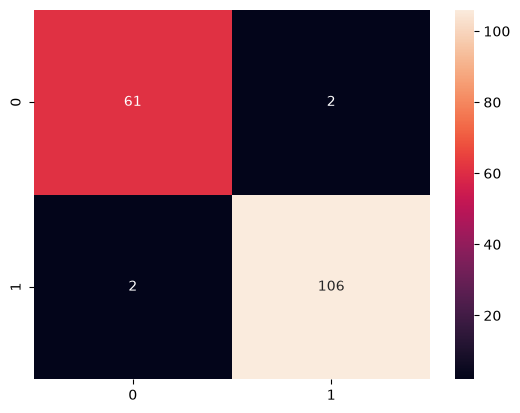

In [6]:
cm=confusion_matrix(y_test,preds)
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

## Accuracy, Recall and Precision

In [7]:
print("Accuracy",accuracy_score(y_test,preds))
print("Recall",recall_score(y_test,preds))
print("Precision",precision_score(y_test,preds))
print("F1",f1_score(y_test,preds))

Accuracy 0.9766081871345029
Recall 0.9814814814814815
Precision 0.9814814814814815
F1 0.9814814814814815


## ROC Curve and AUC

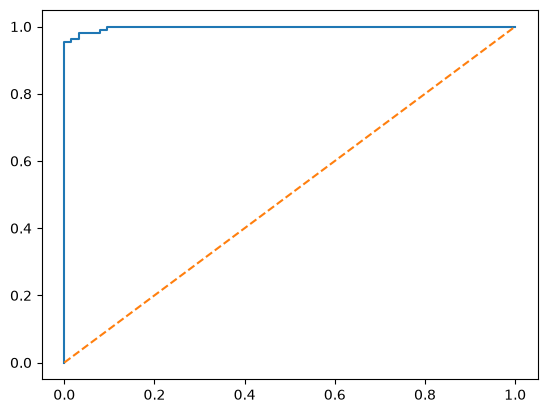

AUC 0.9976484420928865


In [8]:
fpr,tpr,_=roc_curve(y_test,probs)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],"--")
plt.show()
print("AUC",roc_auc_score(y_test,probs))

## Regularisation

In [9]:
for c in [0.01,0.1,1,10]:
    m=LogisticRegression(C=c,max_iter=5000)
    m.fit(X_train,y_train)
    print(c,m.score(X_test,y_test))

0.01 0.9649122807017544


0.1 0.9649122807017544


1 0.9766081871345029


10 0.9707602339181286


C:\Users\phucl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Example 2: Multiclass Classification with Iris

In [10]:
iris=load_iris(as_frame=True)
X=iris.data
y=iris.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
clf=LogisticRegression(max_iter=5000)
clf.fit(X_train,y_train)
print(classification_report(y_test,clf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Feature Selection

In [11]:
selector=SelectKBest(mutual_info_classif,k=5)
selector.fit(X_train,y_train)
print(X.columns[selector.get_support()])

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')


C:\Users\phucl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=5 is greater than n_features=4. All the features will be returned.
  warnings.warn(


## Decision Trees

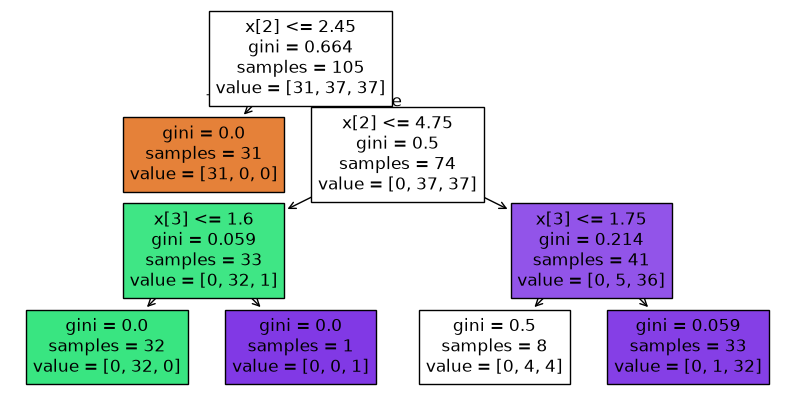

In [12]:
tree=DecisionTreeClassifier(max_depth=3,random_state=42)
tree.fit(X_train,y_train)
plt.figure(figsize=(10,5))
plot_tree(tree,filled=True)
plt.show()

## Random Forests

In [13]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
print("Accuracy",rf.score(X_test,y_test))

Accuracy 1.0


## Variable Importance

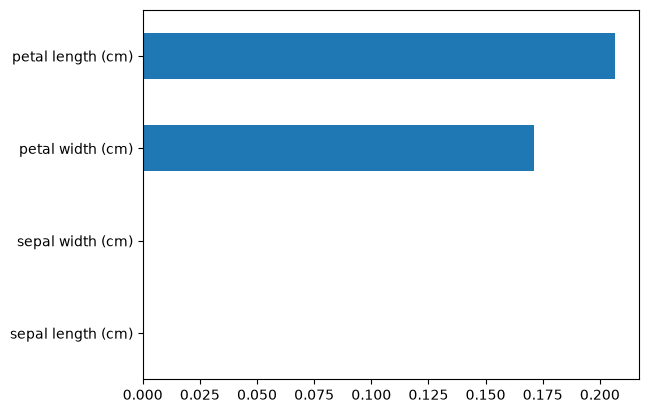

In [14]:
imp=permutation_importance(rf,X_test,y_test,n_repeats=10,random_state=42)
pd.Series(imp.importances_mean,index=X.columns).sort_values().plot.barh()
plt.show()

## Validation Set Approach

In [15]:
scores=cross_val_score(rf,X,y,cv=5)
print(scores)
print(scores.mean())

[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
0.9666666666666668


## LOOCV and K-fold CV

In [16]:
cv=KFold(n_splits=10,shuffle=True,random_state=42)
print(cross_val_score(rf,X,y,cv=cv).mean())

0.9600000000000002


## Overfitting Example

In [17]:
X,y=make_classification(n_samples=500,n_features=20,n_informative=3,random_state=42)
Xtr,Xte,ytr,yte=train_test_split(X,y,random_state=42)
for d in [1,3,10,None]:
    m=DecisionTreeClassifier(max_depth=d,random_state=42)
    m.fit(Xtr,ytr)
    print(d,m.score(Xtr,ytr),m.score(Xte,yte))

1 0.8773333333333333 0.848
3 0.9573333333333334 0.928
10 1.0 0.904
None 1.0 0.904


## Activities
1. Change classification thresholds and compare recall and precision.
2. Compare logistic regression, decision trees and random forests.
3. Repeat feature selection with different numbers of predictors.
4. Investigate overfitting by increasing tree depth.
5. Compare 5-fold and 10-fold cross-validation.

In [18]:
# Activities: fresh copies of the data so that earlier cells cannot interfere
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Xc, yc = load_breast_cancer(return_X_y=True, as_frame=True)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.3, random_state=42)

In [19]:
# Activity 1: classification thresholds (in this dataset class 1 = benign, class 0 = malignant)
logit = LogisticRegression(max_iter=5000).fit(Xc_train, yc_train)
p_benign = logit.predict_proba(Xc_test)[:, 1]

rows = []
for t in [0.1, 0.3, 0.5, 0.7, 0.9, 0.97]:
    pred = (p_benign > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yc_test, pred).ravel()
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(yc_test, pred),
        "benign_precision": precision_score(yc_test, pred, zero_division=0),
        "benign_recall": recall_score(yc_test, pred),
        "malignant_recall": recall_score(yc_test, pred, pos_label=0),
        "missed_malignant": fp,
        "false_alarms": fn,
    })
pd.DataFrame(rows).round(3)

,threshold,accuracy,benign_precision,benign_recall,malignant_recall,missed_malignant,false_alarms
0,0.10,0.959,0.955,0.981,0.921,5,2
1,0.30,0.965,0.964,0.981,0.937,4,2
2,0.50,0.977,0.981,0.981,0.968,2,2
3,0.70,0.971,0.990,0.963,0.984,1,4
4,0.90,0.930,1.000,0.889,1.000,0,12
5,0.97,0.883,1.000,0.815,1.000,0,20


**My answer (Activity 1: thresholds)**

In this dataset class 1 is **benign** and class 0 is **malignant**, so "recall" in the notebook means the share of benign tumours found. The table also shows how many malignant tumours were missed (`missed_malignant`) and how many benign ones were wrongly flagged as malignant (`false_alarms`).

| Threshold | Accuracy | Benign precision | Benign recall | Malignant recall | Missed malignant | False alarms |
|---|---|---|---|---|---|---|
| 0.10 | 0.959 | 0.955 | 0.981 | 0.921 | 5 | 2 |
| 0.30 | 0.965 | 0.964 | 0.981 | 0.937 | 4 | 2 |
| **0.50** | **0.977** | 0.981 | 0.981 | 0.968 | 2 | 2 |
| 0.70 | 0.971 | 0.990 | 0.963 | 0.984 | 1 | 4 |
| 0.90 | 0.930 | 1.000 | 0.889 | 1.000 | 0 | 12 |
| 0.97 | 0.883 | 1.000 | 0.815 | 1.000 | 0 | 20 |

Raising the threshold makes the model more demanding before it says "benign": **precision rises** (0.955 to 1.000) and **recall falls** (0.981 to 0.815). Accuracy is highest near 0.5, but accuracy treats both mistakes as equal. If missing a cancer is worse than a false alarm, a higher threshold such as 0.7 to 0.9 is preferable: at 0.9 no malignant tumour is missed, at the price of 12 benign cases being flagged for further checks. The threshold is a decision about costs, not a fact in the data.

In [20]:
# Activity 2: compare three classifiers with 5-fold cross-validation and on the test set
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
candidates = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "Decision tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

rows = []
for name, mdl in candidates.items():
    res = cross_validate(mdl, Xc, yc, cv=cv5, scoring=["accuracy", "roc_auc"])
    mdl.fit(Xc_train, yc_train)
    rows.append({
        "model": name,
        "CV_accuracy": res["test_accuracy"].mean(),
        "CV_accuracy_sd": res["test_accuracy"].std(),
        "CV_AUC": res["test_roc_auc"].mean(),
        "test_accuracy": mdl.score(Xc_test, yc_test),
    })
pd.DataFrame(rows).round(3)

,model,CV_accuracy,CV_accuracy_sd,CV_AUC,test_accuracy
0,Logistic regression,0.974,0.017,0.995,0.982
1,Decision tree (depth 3),0.924,0.021,0.934,0.965
2,Random forest,0.954,0.010,0.990,0.971


**My answer (Activity 2: comparing models)** (breast cancer data, 5-fold CV, test split with the same seed; logistic regression is scaled)

| Model | CV accuracy (± SD) | CV AUC | Test accuracy |
|---|---|---|---|
| Logistic regression | **0.974 ± 0.017** | **0.995** | 0.982 |
| Random forest | 0.954 ± 0.010 | 0.990 | 0.971 |
| Decision tree (depth 3) | 0.924 ± 0.021 | 0.934 | 0.965 |

**Logistic regression is best** here, then the random forest, then the single tree. This is plausible: the two classes in this dataset are close to linearly separable, so a simple linear model does very well, and the forest has no room to improve on it. The single tree is clearly the weakest on cross-validation and AUC. I trust the cross-validated numbers more than the test accuracy, because the test set (171 samples) gives differences of only one or two cases between the models.

In [21]:
# Activity 3: feature selection with different numbers of predictors (Iris)
from functools import partial

iris_a = load_iris(as_frame=True)
Xi, yi = iris_a.data, iris_a.target
Xi_train, Xi_test, yi_train, yi_test = train_test_split(Xi, yi, test_size=0.3, random_state=42)

rows = []
for k in [1, 2, 3, 4]:
    sel = SelectKBest(partial(mutual_info_classif, random_state=42), k=k).fit(Xi_train, yi_train)
    cols = list(Xi.columns[sel.get_support()])
    rf_k = RandomForestClassifier(n_estimators=200, random_state=42).fit(Xi_train[cols], yi_train)
    rows.append({"k": k, "selected": ", ".join(cols), "test_accuracy": rf_k.score(Xi_test[cols], yi_test)})
pd.DataFrame(rows).round(3)

,k,selected,test_accuracy
0,1,petal length (cm),0.956
1,2,"petal length (cm), petal width (cm)",1.000
2,3,"sepal length (cm), petal length (cm), petal wi...",1.000
3,4,"sepal length (cm), sepal width (cm), petal len...",1.000


**My answer (Activity 3: number of predictors)** (Iris, random forest, test accuracy)

| k | Selected features | Test accuracy |
|---|---|---|
| 1 | petal length | 0.956 |
| 2 | petal length, petal width | **1.000** |
| 3 | + sepal length | 1.000 |
| 4 | all four | 1.000 |

One feature already gives 0.956, and **the two petal measurements are enough for 1.000**. Adding more features does not help on this test set. This agrees with the importance results (petal length and petal width matter, the sepal measurements add nothing).

Two cautions. First, the mutual-information scores of petal length and petal width are almost tied (about 0.94 to 0.97 across random seeds), so which one is chosen when `k = 1` depends on the random seed; I fixed `random_state=42` so the result is repeatable, and with a different seed the selected feature, and its test accuracy, can change. Second, the test set has only 45 flowers, so one mistake changes accuracy by about 2 percentage points; this is a rough comparison. The notebook's own cell used `k=5` on Iris, which only has 4 features, so it simply returned all four.

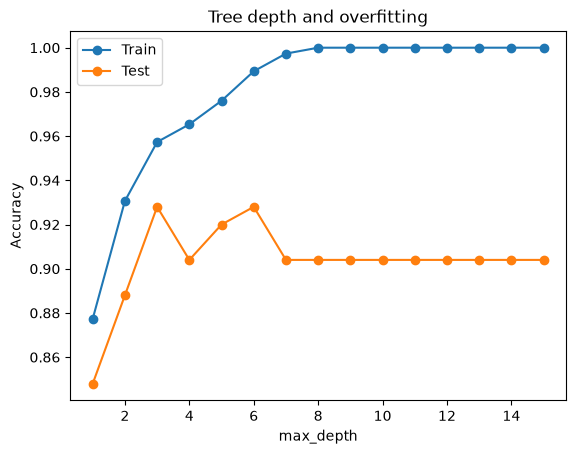

,max_depth,train,test
0,1,0.877,0.848
1,2,0.931,0.888
2,3,0.957,0.928
3,4,0.965,0.904
4,5,0.976,0.920
5,6,0.989,0.928
6,7,0.997,0.904
7,8,1.000,0.904
8,9,1.000,0.904
9,10,1.000,0.904


In [22]:
# Activity 4: overfitting as tree depth increases
Xs, ys = make_classification(n_samples=500, n_features=20, n_informative=3, random_state=42)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(Xs, ys, random_state=42)

depths = list(range(1, 16))
train_acc, test_acc = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(Xs_train, ys_train)
    train_acc.append(m.score(Xs_train, ys_train))
    test_acc.append(m.score(Xs_test, ys_test))

plt.plot(depths, train_acc, marker="o", label="Train")
plt.plot(depths, test_acc, marker="o", label="Test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Tree depth and overfitting")
plt.legend()
plt.show()
pd.DataFrame({"max_depth": depths, "train": train_acc, "test": test_acc}).round(3)

**My answer (Activity 4: tree depth and overfitting)**

Training accuracy keeps rising with depth and reaches **1.000 from depth 8**, while test accuracy stays between **0.904 and 0.928** and stops improving after depth 3 (0.928) and 6 (0.928). So deeper trees only memorise the training data.

| Depth | Train | Test | Gap |
|---|---|---|---|
| 1 | 0.877 | 0.848 | 0.029 (underfits: both low) |
| 3 | 0.957 | 0.928 | 0.029 |
| 6 | 0.989 | 0.928 | 0.061 |
| 8 and above | 1.000 | 0.904 | 0.096 |

The train/test gap grows from about 0.03 to about 0.10 as the tree gets deeper, which is the signature of overfitting. The data has 20 features of which only 3 are informative, so a deep tree has many chances to fit noise. Test accuracy is measured on 125 samples, so the differences between 0.904 and 0.928 are only about three samples; I would choose a **shallow tree (depth about 3)** because it performs as well as deeper ones and is simpler.

In [23]:
# Activity 5: 5-fold versus 10-fold cross-validation (random forest on Iris), repeated with 10 different shuffles
rows = []
for k in [5, 10]:
    means = [
        cross_val_score(
            RandomForestClassifier(n_estimators=200, random_state=42), Xi, yi,
            cv=StratifiedKFold(n_splits=k, shuffle=True, random_state=s)
        ).mean()
        for s in range(10)
    ]
    rows.append({"folds": k, "mean_accuracy": np.mean(means), "sd_across_shuffles": np.std(means)})
pd.DataFrame(rows).round(4)

,folds,mean_accuracy,sd_across_shuffles
0,5,0.9507,0.0085
1,10,0.9553,0.0060


**My answer (Activity 5: 5-fold versus 10-fold)** (random forest on Iris, repeated with 10 different shuffles)

| Folds | Mean accuracy | SD across shuffles |
|---|---|---|
| 5 | 0.9507 | 0.0085 |
| 10 | 0.9553 | 0.0060 |

The two estimates differ by about 0.005, which is **smaller than the variation caused by the random shuffling itself** (SD 0.006 to 0.009). So there is no meaningful difference in this example. 10-fold trains each model on 90% of the data instead of 80% and gave slightly less variable results, but it costs twice as many model fits. On a small dataset like Iris either is fine; the more important point is to report a cross-validated average rather than a single train/test split.